# Text Classification Using Various Models with Movie Reviews from IMDB

In [ ]:
# Install the following packages if you do not have them
!pip install pandas numpy vaderSentiment textblob matplotlib seaborn bs4 contractions

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re
import contractions

#STEP 1: Choose Dataset

Dataset: IMDB Dataset of 50K Movie Reviews

This dataset contains only the review of the movies and the sentiment that the review is dictated to have. We are going to use the sentiment column to compare the results we get from the model.

In [6]:
movie_review_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment2\data\raw\IMDB Dataset.csv", header=0, encoding="utf-8")
movie_review_df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


STEP 2: Exploring the Dataset

This includes finding out what the dataset is made up of, where there is missing data information, the data types of the columns in the dataset, and the overall distribution of the reviews and sentiments.

There are 50000 in this dataset


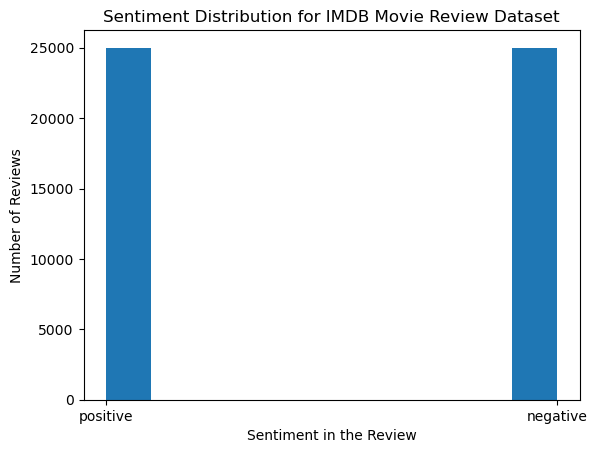

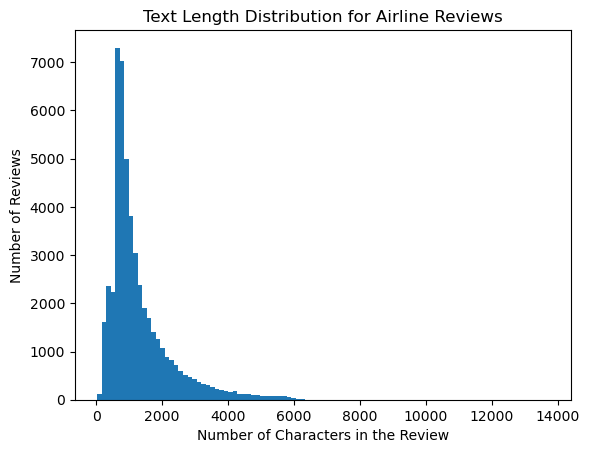

In [8]:
#2.1 Metadata of the Dataset

#2.1.1 Number of rows
#Store the number of rows in a variable
num_rows=len(movie_review_df)

#Print the clear number
print(f"There are {num_rows} in this dataset")

#2.1.2 Columns
movie_review_df.columns
#Column 1 ("review"): This column is made up of strings that are comprised of reviews

#Column 2 ("sentiment"): This column is comprised of strings that either read positive or negative.
movie_review_df['sentiment'].unique()

#2.1.3 Data Types
movie_review_df.dtypes
#Column 1 ("review"): This column is made up of strings
#Column 2 ("sentiment"): This column as it sits right now is made up of strings. If we looked at the code and made some slight adjustments it could be a boolean.

#2.1.4 Missing Values

#There are no missing values in this dataset.
movie_review_df.isna().sum()

#2.1.5 Target Distribution????

#2.2 Class Distribution

#Show a histogram for the distribution of the Sentiment reviews
plt.hist(movie_review_df['sentiment'])
plt.xlabel("Sentiment in the Review")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution for IMDB Movie Review Dataset")
#Save the Figure as a .png file
#plt.savefig("sentiment_distribution_hist.png")
plt.show()

#2.1.1 Is the dataset balanced?

#Shows a histogram for the length of the reviews in characters
#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=movie_review_df["review"].str.len()
#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for Airline Reviews")
#Save the Figure as a .png file
#plt.savefig("text_length_distribution_hist.png")
plt.show()

#Looking at the distribution of review sentiment from the sentiment column, we can see that the distribution is exactly even.



In [34]:
# STEP 3: Pre-Processing

#Function that removes any HTML Tags that may exist in the reviews
def clean_text(text):
    return BeautifulSoup(text, "html.parser").get_text()

#Step 3.1.3
#Function that removes special characters from the text
def remove_spec_char(text):
    return re.sub(r'[^a-zA-Z0-9. !?]', ' ', text)

#Step 3.1.4
#Function that expands contractions so we can properly vectorize
def expand_contractions_text(text):
    return contractions.fix(text)


#Step 3.1.6
#Text to remove any extra spaces in between and at the beginning of the text
def remove_extra_spaces(text):
    outer_space_clean=text.strip()
    final_clean= " ".join(text.split())
    return final_clean

In [36]:
movie_review_df['clean_reviews']= movie_review_df['review'].apply(clean_text)
movie_review_df['clean_reviews']= movie_review_df['clean_reviews'].apply(remove_spec_char)
movie_review_df['clean_reviews']= movie_review_df['clean_reviews'].apply(expand_contractions_text)
movie_review_df['clean_reviews']= movie_review_df['clean_reviews'].apply(remove_extra_spaces)

C:\Users\ysass\AppData\Local\Temp\ipykernel_11604\530742394.py:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [38]:
movie_review_df

,review,sentiment,clean_reviews
0,One of the other reviewers has mentioned that ...,positive,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,positive,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,Basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,Petter Mattei s Love in the Time of Money is a...
...,...,...,...
49995,I thought this movie did a down right good job...,positive,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,Bad plot bad dialogue bad acting idiotic direc...
49997,I am a Catholic taught in parochial elementary...,negative,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...,negative,I m going to have to disagree with the previou...
